In [2]:
import os 
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
MASTER_DIR = Path(r"D:\Automotive\Race Strategy Decision Support System (RSDSS)\Race-Strategy-Decision-Support-System-RSDSS-\Data\Processed\Master\Master_Dataset.csv")
df = pd.read_csv(MASTER_DIR)

In [4]:
df = df[df["ValidLap"]].copy()

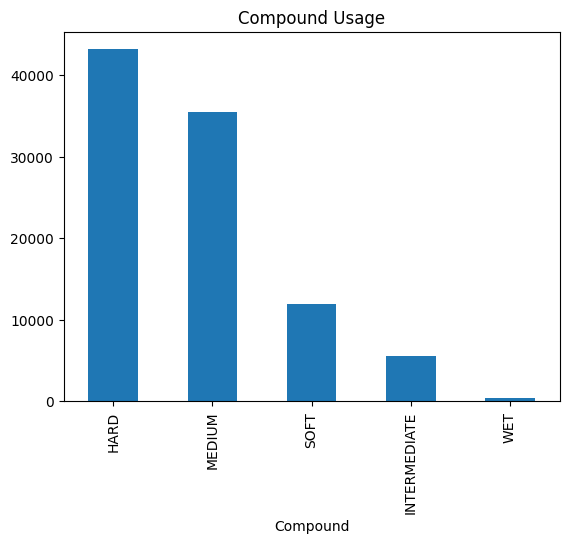

In [5]:
compound = df["Compound"].value_counts()

compound.plot(kind="bar")

plt.title("Compound Usage")

plt.show()

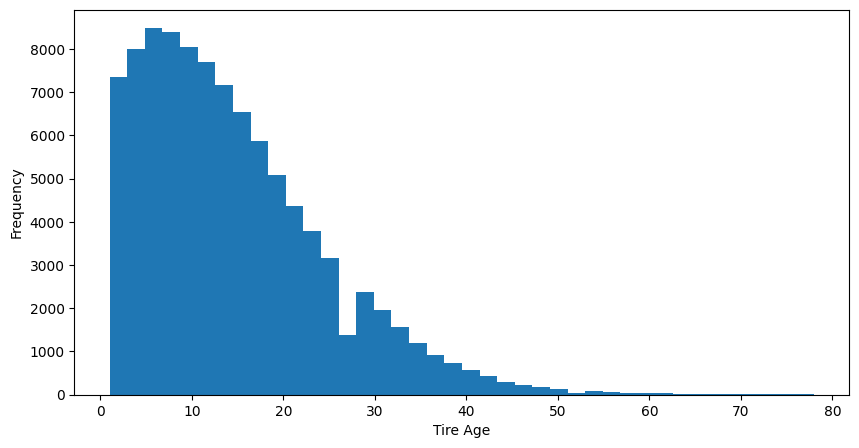

In [6]:
plt.figure(figsize=(10,5))

plt.hist(df["TireAge"], bins=40)

plt.xlabel("Tire Age")

plt.ylabel("Frequency")

plt.show()

In [7]:
stints = (
    df.groupby(["Driver","RaceID","Stint"])
      ["TireAge"]
      .max()
)

stints.describe()

count    4856.000000
mean       20.888180
std        11.540019
min         1.000000
25%        13.000000
50%        20.000000
75%        28.000000
max        78.000000
Name: TireAge, dtype: float64

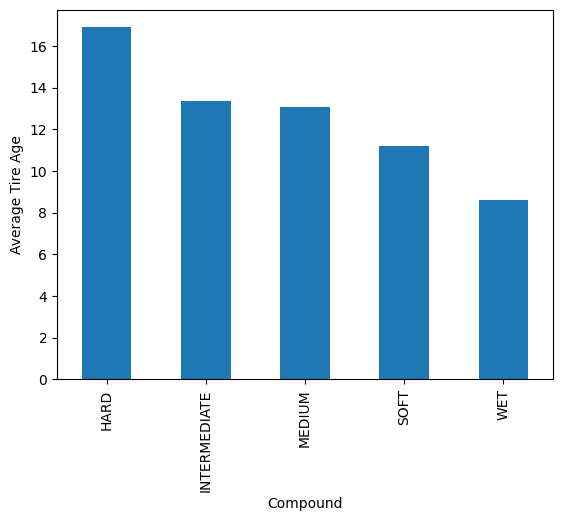

In [8]:
compound_stints = (
    df.groupby("Compound")["TireAge"]
      .mean()
)

compound_stints.plot(kind="bar")

plt.ylabel("Average Tire Age")

plt.show()

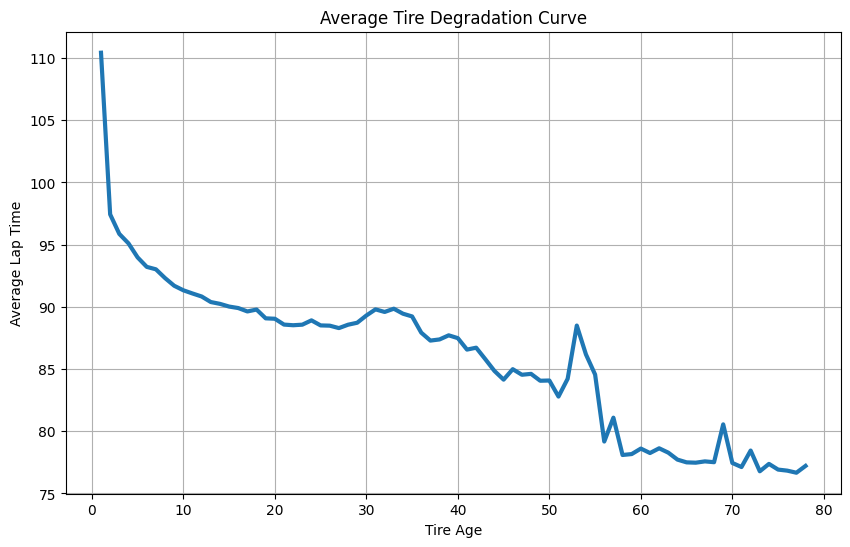

In [9]:
deg = (
    df.groupby("TireAge")["LapTime_Seconds"]
      .mean()
)

plt.figure(figsize=(10,6))

plt.plot(
    deg.index,
    deg.values,
    linewidth=3
)

plt.xlabel("Tire Age")

plt.ylabel("Average Lap Time")

plt.title("Average Tire Degradation Curve")

plt.grid(True)

plt.show()

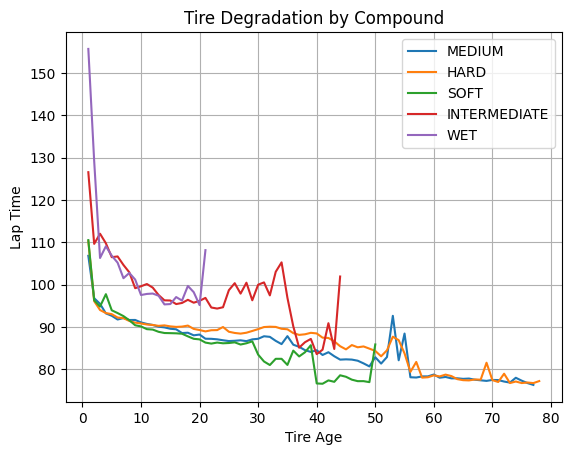

In [10]:
for compound in df["Compound"].dropna().unique():

    subset = df[df["Compound"] == compound]

    curve = (
        subset.groupby("TireAge")
              ["LapTime_Seconds"]
              .mean()
    )

    plt.plot(
        curve.index,
        curve.values,
        label=compound
    )

plt.legend()

plt.xlabel("Tire Age")

plt.ylabel("Lap Time")

plt.title("Tire Degradation by Compound")

plt.grid(True)

plt.show()

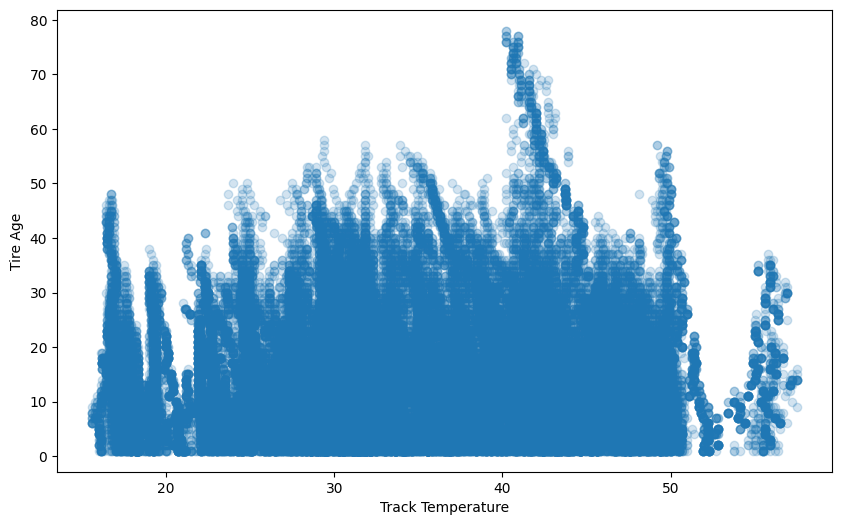

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["TrackTemp"],
    df["TireAge"],
    alpha=0.2
)

plt.xlabel("Track Temperature")

plt.ylabel("Tire Age")

plt.show()

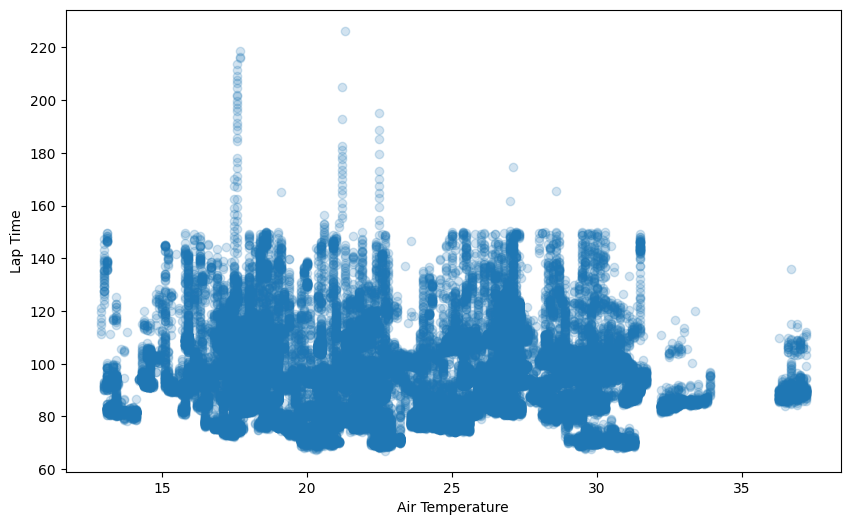

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["AirTemp"],
    df["LapTime_Seconds"],
    alpha=0.2
)

plt.xlabel("Air Temperature")

plt.ylabel("Lap Time")

plt.show()

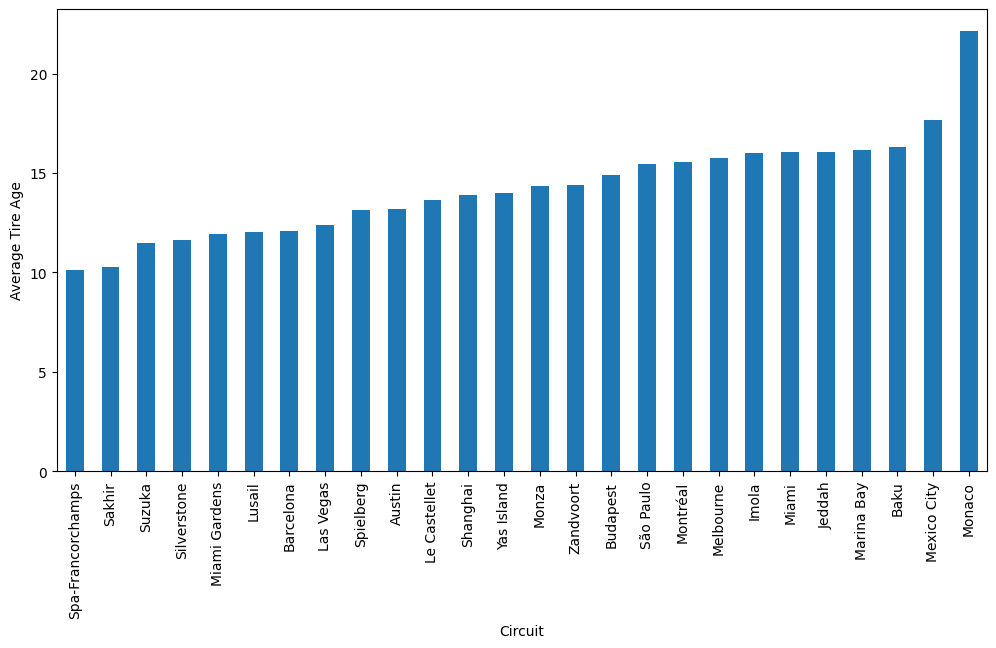

In [13]:
avg = (
    df.groupby("Circuit")["TireAge"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

avg.plot(kind="bar")

plt.ylabel("Average Tire Age")

plt.show()

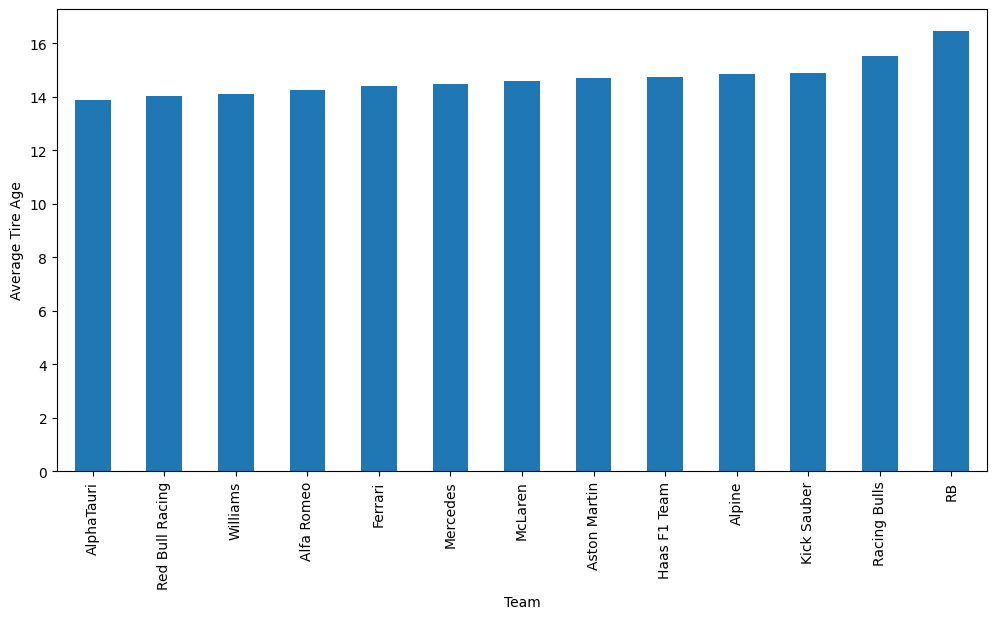

In [14]:
avg = (
    df.groupby("Team")["TireAge"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

avg.plot(kind="bar")

plt.ylabel("Average Tire Age")

plt.show()

## Conclusion

- Tire degradation follows a clear upward trend as tire age increases.
- Soft compounds generally exhibit faster degradation than Medium and Hard compounds.
- Higher track temperatures tend to accelerate tire degradation.
- Stint lengths vary considerably across compounds and circuits, highlighting the importance of race context in pit strategy optimization.
- Tire age, compound, and track temperature emerge as key candidate features for predictive modelling.